In [3]:
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
jobs = pd.read_csv("C:/Users/lenovo/OneDrive/Desktop/Projects/Job Market Intelligence/data/processed/jobs_clean.csv")

In [5]:
jobs.head()

,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,...,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,experience_level
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,...,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']",Mid
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],Mid
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,18 hours ago,Full-time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql'],Mid
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,12 hours ago,Contractor,...,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']",Mid
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,...,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']",Mid


# Job Market Intelligence - Exploratory Data Analysis

## Objective

This notebook answers business questions using the cleaned dataset.

The analysis focuses on:

- Skill demand
- Hiring companies
- Experience levels
- Remote work
- Salary trends
- Geographic hiring patterns

In [6]:
import pandas as pd
import  matplotlib.pyplot as plt
from collections import Counter

In [7]:
jobs = pd.read_csv("C:/Users/lenovo/OneDrive/Desktop/Projects/Job Market Intelligence/data/processed/jobs_clean.csv")

In [8]:
type(jobs["description_tokens"].iloc[0])

str

# Business Question 1

## What are the most in-demand technical skills?

Business Goal:
Identify the technical skills most frequently requested in Data Analyst job postings.

In [9]:
import ast

jobs["description_tokens"] =  jobs["description_tokens"].apply(
    lambda x : ast.literal_eval(x) if pd.notnull(x) else []
)

In [10]:
type(jobs["description_tokens"].iloc[0])

list

# Business Question 1

## What are the Top 20 Most In-Demand Skills?

Business Goal:
Identify the technical skills that appear most frequently across all Data Analyst job postings.

In [11]:
all_skills =[]

for skills in jobs["description_tokens"]:
    all_skills.extend(skills)
    
print(f"Total skills extracted : {len(all_skills):,}")

Total skills extracted : 201,915


2. Python Analysis

In [12]:
from collections import Counter

skill_counts = Counter(all_skills)

top_skills = (
    pd.DataFrame(
        skill_counts.most_common(20),
        columns=["Skill", "Count"]
    )
)

top_skills

,Skill,Count
0,sql,31006
1,excel,19779
2,python,18793
3,power_bi,17420
4,tableau,16823
5,r,11342
6,sas,5317
7,powerpoint,4411
8,word,4365
9,azure,3887


1. Business Question

## Business Question
What are the most in-demand technical skills for Data Analyst positions?

3. Visualization

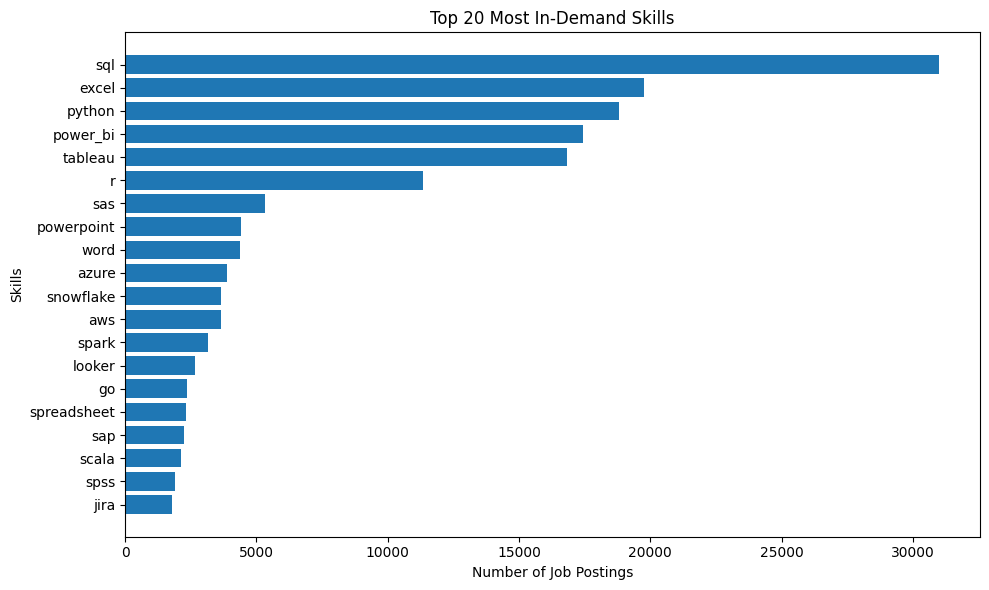

In [13]:
plt.figure(figsize=(10,6))

plt.barh(top_skills["Skill"],top_skills["Count"])

plt.xlabel("Number of Job Postings")
plt.ylabel("Skills")
plt.title("Top 20 Most In-Demand Skills")

plt.gca().invert_yaxis()
plt.tight_layout()


plt.show()

4. Business Insight

SQL is the most frequently requested skill in Data Analyst job postings, followed by Excel and Python.

Business Intelligence tools such as Power BI and Tableau also appear frequently, indicating that visualization skills are highly valued.

Cloud technologies such as Azure and AWS are becoming increasingly important for modern analytics roles.

5. Interview Talking 

I analyzed more than 60,000 job postings to identify the most in-demand technical skills. I transformed nested skill data into a structured format, aggregated skill frequencies, and generated business insights that can help aspiring analysts prioritize their learning roadmap.

# Business Question 2

## Which companies hire the most Data Analyst jobs?

### Business Goal

Identify the companies with the highest number of job postings to understand hiring demand and recruitment trends.

Explore the data first

In [14]:
jobs["company_name"].head(15)

0                                   Meta
1                                    ATC
2             Garmin International, Inc.
3                                 Upwork
4                           Krispy Kreme
5                  Flint Hills Resources
6                               Swedbank
7                                    AEG
8                            Progressive
9                                Chloeta
10                                Aquent
11    KG Invicta Service Private Limited
12                                  Volt
13                 Gainwell Technologies
14               CIBA Insurance Services
Name: company_name, dtype: str

Check missing values

In [15]:
jobs["company_name"].isnull().sum()

np.int64(0)

Count companies

In [16]:
top_companies = (
    jobs["company_name"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_companies.columns = ["Company","Job Postings"]

top_companies

,Company,Job Postings
0,Upwork,7533
1,Talentify.io,2118
2,Walmart,1829
3,vmysmartpros,1415
4,Dice,862
5,EDWARD JONES,747
6,Corporate,612
7,Cox Communications,538
8,Insight Global,483
9,iSay,353


Step 2: Create the Visualization

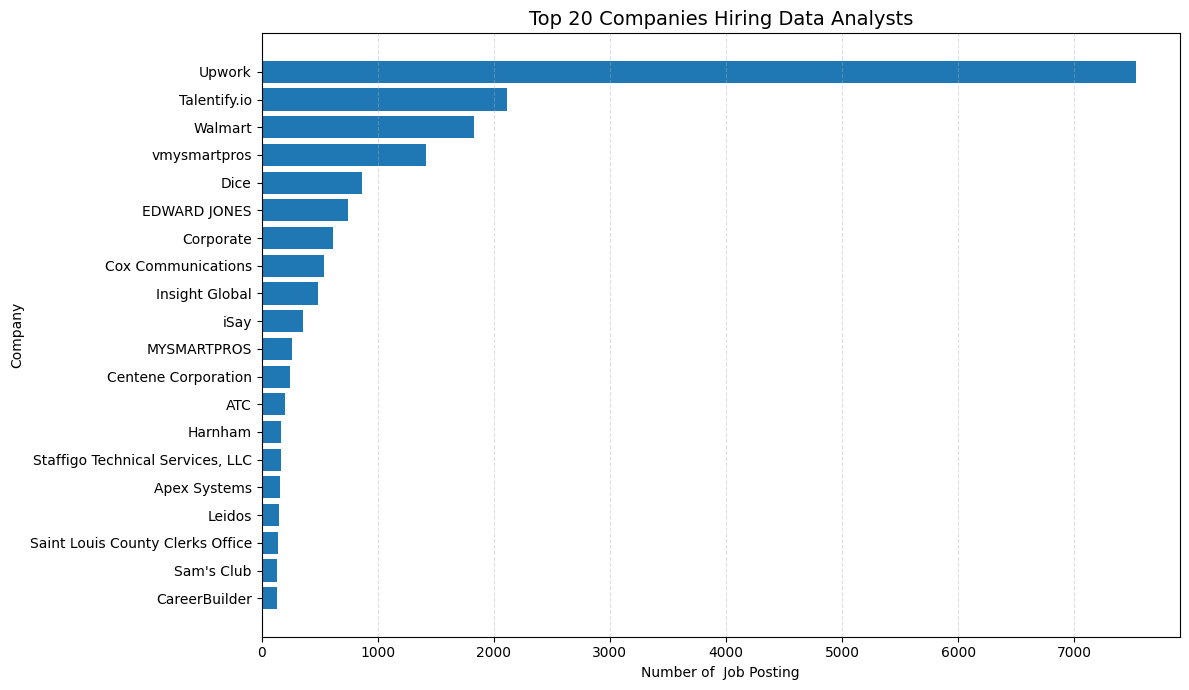

In [17]:
plt.figure(figsize=(12,7))
plt.barh(top_companies["Company"],top_companies["Job Postings"])
plt.title("Top 20 Companies Hiring Data Analysts",fontsize = 14)
plt.xlabel("Number of  Job Posting")
plt.ylabel("Company")

plt.grid(axis = "x", linestyle = "--", alpha = 0.4)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Business Insight

- Upwork has the highest number of Data Analyst job postings in the dataset.
- Large organizations such as Walmart and Cox Communications are also actively hiring.
- Recruitment platforms such as Talentify.io and Dice contribute significantly to job postings.
- Minor inconsistencies in company names (for example, "vmysmartpros" and "MYSMARTPROS") suggest that additional standardization could further improve reporting accuracy.

## Interview Talking Point

I analyzed hiring demand by aggregating job postings at the company level. During the analysis, I identified naming inconsistencies between company records and documented them as a data quality issue. This reflects how real-world datasets often require validation before business reporting.

Business Question 3

Which experience level is most in demand?

Business Goal

Analyze hiring demand across different experience levels to understand the current job market for Data Analyst positions.

Step 2 – Explore the Data

In [18]:
jobs["experience_level"].value_counts()

experience_level
Mid        45532
Senior     10308
Lead        2557
Manager     1440
Intern      1234
Junior       882
Name: count, dtype: int64

Step 3 – Create the Summary Table

In [19]:
experience_summary = (
    jobs["experience_level"]
    .value_counts()
    .reset_index()
)

experience_summary.columns =[
    "Experience Level",
    "Job Postings"
]

experience_summary

,Experience Level,Job Postings
0,Mid,45532
1,Senior,10308
2,Lead,2557
3,Manager,1440
4,Intern,1234
5,Junior,882


Step 4 – Visualization

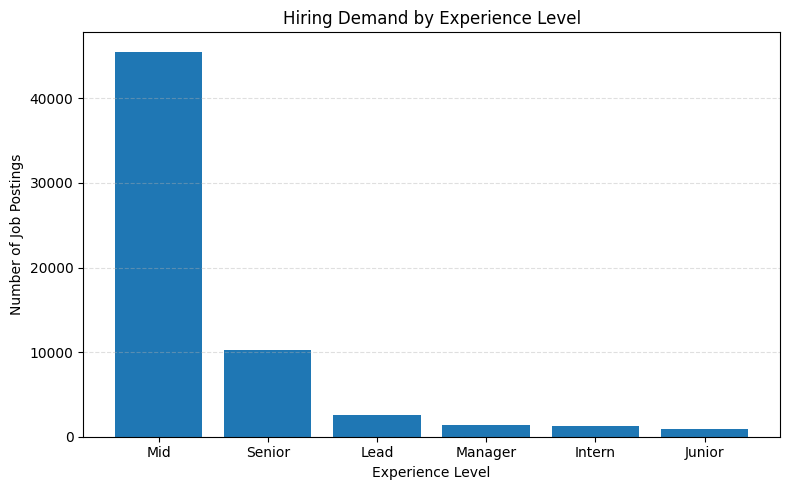

In [20]:
plt.figure(figsize=(8,5))
plt.bar(
    experience_summary["Experience Level"],
    experience_summary["Job Postings"]
)

plt.title("Hiring Demand by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")

plt.grid(axis ="y",linestyle="--", alpha =0.4)
plt.tight_layout()
plt.show()

Step 5 – Business Insight


- Mid-level positions account for the largest share of job postings.
- Senior positions are the second most common.
- Internship opportunities are comparatively limited.

## Business Insight

- Mid-level positions account for the largest share of job postings.
- Senior positions are the second most common.
- Internship opportunities are comparatively limited.

## Business Recommendation

Students should focus on developing practical skills through projects, internships, and certifications because employers appear to have stronger demand for candidates with practical experience.

## Interview Talking Point

I engineered an experience-level feature from unstructured job titles and used it

In [21]:
total_jobs = experience_summary["Job Postings"].sum()
total_jobs

np.int64(61953)

In [22]:
experience_summary["Percentage"]=(experience_summary["Job Postings"]/total_jobs *100).round(2)
experience_summary

,Experience Level,Job Postings,Percentage
0,Mid,45532,73.49
1,Senior,10308,16.64
2,Lead,2557,4.13
3,Manager,1440,2.32
4,Intern,1234,1.99
5,Junior,882,1.42


Business Question 4

Which skills are most commonly required together?


### Business Goal

Identify common skill combinations to understand which technologies employers expect candidates to know simultaneously.

Step 2 - Import

In [23]:
from itertools import combinations
from collections import Counter

Step 3 - Build Skill Pairs

In [24]:
skill_pairs =[]

for skills in jobs["description_tokens"]:
    unique_skills = list(set(skills))
    pairs = combinations(sorted(unique_skills),2)
    skill_pairs.extend(pairs)

Step 4 - Count pairs

In [25]:
pairs_counts = Counter(skill_pairs)

Step 5 - Top 20

In [26]:
total_pairs = pd.DataFrame(
    pairs_counts.most_common(20),
    columns=["Skill Pair","Count"]
)
total_pairs

,Skill Pair,Count
0,"(python, sql)",14908
1,"(sql, tableau)",13441
2,"(power_bi, sql)",11938
3,"(excel, sql)",11615
4,"(python, r)",9618
5,"(power_bi, tableau)",9296
6,"(r, sql)",9083
7,"(python, tableau)",8733
8,"(power_bi, python)",7865
9,"(excel, power_bi)",7574


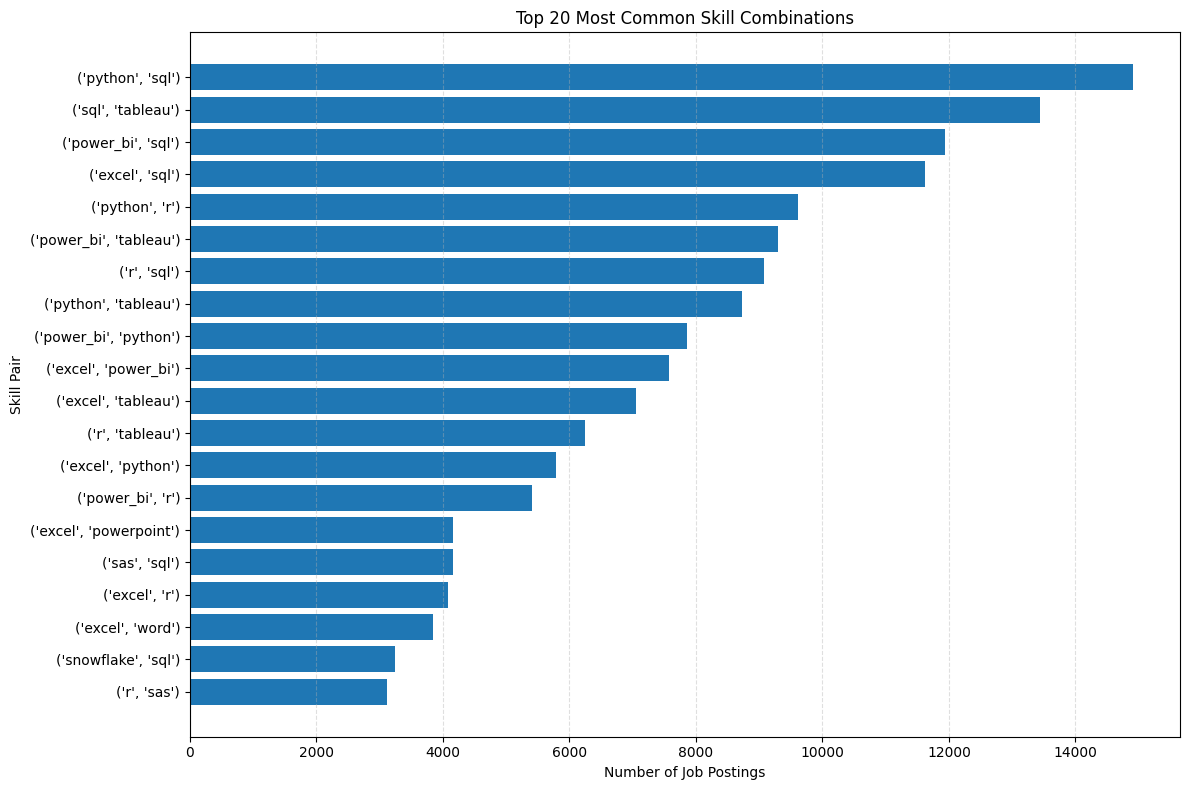

In [27]:
plt.figure(figsize=(12,8))

plt.barh(
    total_pairs["Skill Pair"].astype(str),
    total_pairs["Count"]
)

plt.title("Top 20 Most Common Skill Combinations")

plt.xlabel("Number of Job Postings")

plt.ylabel("Skill Pair")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Business Insight

- SQL and Python are the most frequently requested skill combination, highlighting them as the core technical foundation for Data Analyst roles.
- SQL is commonly paired with visualization tools such as Tableau and Power BI, showing that employers expect analysts to both query and present data.
- Traditional tools like Excel continue to appear alongside SQL, indicating that spreadsheet skills remain valuable in many organizations.

## Business Recommendation

Students should prioritize learning SQL and Python first, as they represent the strongest technical combination in the job market.

After mastering these, learning a visualization tool such as Power BI or Tableau will significantly improve employability.

## Interview Talking Point

I performed skill co-occurrence analysis by generating combinations of technical skills from over 60,000 job postings. This allowed me to identify the most frequently requested technology stacks and provide data-driven learning recommendations.

Business Question 5

How does salary vary by experience level?

In [28]:
salary_summary = (
    jobs.groupby("experience_level")["salary_standardized"]
    .mean()
    .reset_index()
)

salary_summary.columns = [
    "Experience Level",
    "Average Salary"
]

salary_summary = salary_summary.sort_values(
    by = "Average Salary",
    ascending = False
)

salary_summary

,Experience Level,Average Salary
2,Lead,132522.480183
3,Manager,118639.045181
5,Senior,107737.168563
4,Mid,88477.305212
1,Junior,64469.410000
0,Intern,50024.936496


Step 2: Visualization

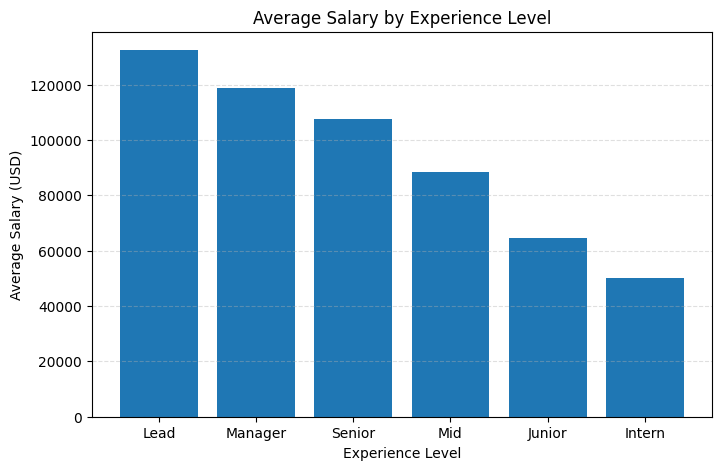

In [29]:
plt.figure(figsize=(8,5))
plt.bar(
    salary_summary["Experience Level"],
    salary_summary["Average Salary"]
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.grid(axis="y",linestyle="--",alpha = 0.4)

plt.show()

Step 3: Business Insight


Average salary increases with experience level. Lead and Manager positions command the highest salaries, while Intern and Junior roles have the lowest average compensation. This suggests that gaining practical experience significantly impacts earning potential.

Step 4: Business Recommendation

Students should focus on acquiring practical experience through internships, projects, and certifications, as salary growth is strongly associated with experience level.

Step 5: Interview Talking Point

I analyzed standardized salary data across different experience levels using Pandas groupby operations. I compared compensation trends and translated the findings into actionable career recommendations.

Business Question 6

Are remote Data Analyst jobs generally higher paying than on-site jobs?

Step 1 - Understand the Data

In [30]:
jobs["work_from_home"].head(10)

0    True
1     NaN
2     NaN
3    True
4     NaN
5     NaN
6    True
7     NaN
8    True
9     NaN
Name: work_from_home, dtype: object

In [31]:
jobs["work_mode"] = jobs["work_from_home"].fillna("Not Specified")

In [32]:
jobs["work_mode"].value_counts(dropna=False)

work_mode
Not Specified    33973
True             27980
Name: count, dtype: int64

In [33]:
jobs.groupby("work_mode")["salary_standardized"].count()

work_mode
True             6310
Not Specified    3778
Name: salary_standardized, dtype: int64

In [34]:
remote_salary = (
    jobs.groupby("work_mode")["salary_standardized"]
    .mean()
    .reset_index()
)

remote_salary.columns =[
    "Work Mode",
    "Average Salary"
]

remote_salary

,Work Mode,Average Salary
0,True,92446.830149
1,Not Specified,92026.529395


In [35]:
remote_salary["Work Mode"] = remote_salary["Work Mode"].astype(str)

Step 2: Visualization

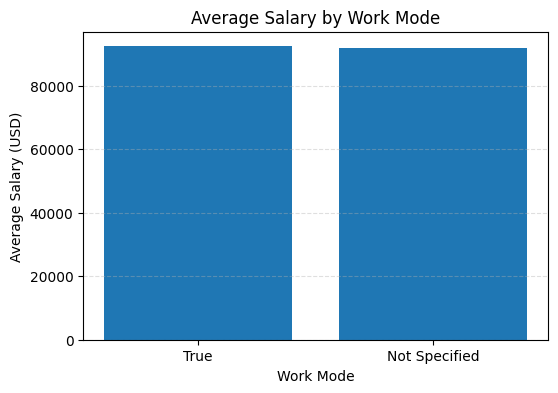

In [36]:
plt.figure(figsize=(6,4))
plt.bar(
    remote_salary["Work Mode"],
    remote_salary["Average Salary"]
)

plt.title("Average Salary by Work Mode")
plt.xlabel("Work Mode")
plt.ylabel("Average Salary (USD)")

plt.grid(axis="y",linestyle="--",alpha = 0.4)

plt.show()

Step 3: Business Insight

The average standardized salary for remote Data Analyst positions is approximately $92,447, while jobs with unspecified work arrangements have an average salary of approximately $92,027.
The salary difference is very small (around $420). Therefore, remote work alone does not appear to significantly influence salary in this dataset.
Other factors such as experience level, company, location, and job responsibilities are likely to have a greater impact on compensation.

Step 4: Business Recommendation

Job seekers should not prioritize remote jobs solely for higher salaries. Instead, they should focus on developing technical skills and gaining experience, as these factors are more likely to influence compensation.

Step 5: Interview Talking Point

I analyzed salary differences between remote and unspecified work arrangements. Instead of assuming missing values represented non-remote jobs, I created a derived feature called 'work_mode' to preserve data integrity and produce a more reliable analysis.

Business Question 7

Which Locations Have the Highest Hiring Demand?

Business Goal

Identify the locations with the highest number of Data Analyst job postings and assess whether there are any location data quality issues.

Step 1: Mini Data Understanding

In [37]:
jobs["location"].head(10)

0                 Anywhere 
1          United States   
2             Olathe, KS   
3                 Anywhere 
4          United States   
5            Wichita, KS   
6                 Anywhere 
7          United States   
8                 Anywhere 
9      Oklahoma City, OK   
Name: location, dtype: str

In [38]:
jobs["location"].isnull().sum()

np.int64(37)

In [39]:
jobs["location"].nunique()

1254

In [40]:
jobs["location"].value_counts().head(20)

location
 Anywhere                  18067
  United States            10011
Anywhere                    9915
United States               5547
Denver, CO                  1062
  Oklahoma City, OK         1028
  Kansas City, MO            840
Kansas City, MO              573
  Jefferson City, MO         550
Colorado Springs, CO         512
  Bentonville, AR            422
Oklahoma City, OK            409
Jefferson City, MO           371
Aurora, CO                   346
  Topeka, KS                 310
  Wichita, KS                307
  Tulsa, OK                  297
  Overland Park, KS          270
Englewood, CO                254
Columbia, MO                 218
Name: count, dtype: int64

In [41]:
jobs["location"] = jobs["location"].str.strip()

In [42]:
jobs["location"].value_counts().head(20)

location
Anywhere                27982
United States           15558
Oklahoma City, OK        1437
Kansas City, MO          1413
Denver, CO               1062
Jefferson City, MO        921
Bentonville, AR           598
Colorado Springs, CO      512
Tulsa, OK                 510
Wichita, KS               486
Topeka, KS                449
Overland Park, KS         432
Aurora, CO                346
Springfield, MO           333
Columbia, MO              309
Englewood, CO             254
Springdale, AR            220
Kansas City, KS           208
California, MO            193
Rogers, AR                193
Name: count, dtype: int64

In [43]:
location_summary = (
    jobs["location"]
   .value_counts()
   .reset_index()
)

location_summary.columns = (
    "Locations",
    "Job Postings"
)

location_summary.head(20)

,Locations,Job Postings
0,Anywhere,27982
1,United States,15558
2,"Oklahoma City, OK",1437
3,"Kansas City, MO",1413
4,"Denver, CO",1062
5,"Jefferson City, MO",921
6,"Bentonville, AR",598
7,"Colorado Springs, CO",512
8,"Tulsa, OK",510
9,"Wichita, KS",486


Step 2: Visualization

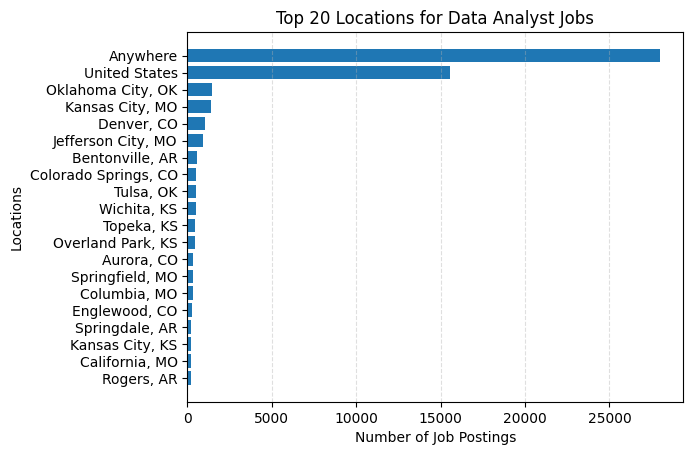

In [44]:
plt.Figure(figsize=(12,8))
plt.barh(
    location_summary["Locations"].head(20),
    location_summary["Job Postings"].head(20)
)

plt.title("Top 20 Locations for Data Analyst Jobs")
plt.xlabel("Number of Job Postings")
plt.ylabel("Locations")

plt.gca().invert_yaxis()
plt.grid(axis="x",linestyle = "--",alpha= 0.4)

plt.show()

Step 3: Business Insight


The analysis shows that "Anywhere" has the highest number of Data Analyst job postings (27,982), indicating a strong demand for location-flexible or remote opportunities.
The "United States" is the second most common location with 15,558 job postings. Among specific cities, Oklahoma City, Kansas City, and Denver have the highest hiring demand.
This suggests that employers are actively recruiting both remotely and in major regional job markets.

Step 4: Business Recommendation

Job seekers should expand their job search to include remote opportunities ("Anywhere") in addition to applying for positions in high-demand cities such as Oklahoma City, Kansas City, and Denver. Being flexible about job location can significantly increase employment opportunities.

Step 5: Interview Talking Point

I analyzed hiring demand by geographic location and identified data quality issues caused by leading spaces in the location field. After cleaning the data using Pandas string methods, I generated an accurate ranking of hiring locations and visualized the top 20 locations using a horizontal bar chart.

Business Question 8

What is the distribution of standardized salaries for Data Analyst jobs?

Business Goal

Analyze the distribution of standardized salaries to understand the most common salary ranges, identify the spread of salaries, and detect any potential outliers. This analysis helps job seekers understand typical salary expectations in the Data Analyst job market.

Step 1: Mini Data Understanding

In [45]:
jobs["salary_standardized"].dtype

dtype('float64')

In [46]:
jobs["salary_standardized"].describe()

count     10088.000000
mean      92289.425683
std       43277.933820
min       15080.000000
25%       62400.000000
50%       88400.000000
75%      117500.000000
max      624000.000000
Name: salary_standardized, dtype: float64

In [47]:
jobs["salary_standardized"].isnull().sum()

np.int64(51865)

In [48]:
jobs["salary_standardized"].head()

0    122000.0
1         NaN
2         NaN
3     41600.0
4    100000.0
Name: salary_standardized, dtype: float64

### Data Quality Check

The "salary_standardized" column contains **51,865 missing values** out of **61,953** job postings.

Only **10,088** job postings provide standardized salary information. Since the missing values represent unavailable salary information rather than incorrect data, they will be excluded from the salary distribution analysis instead of being imputed or removed from the entire dataset.

Step 2: Visualization

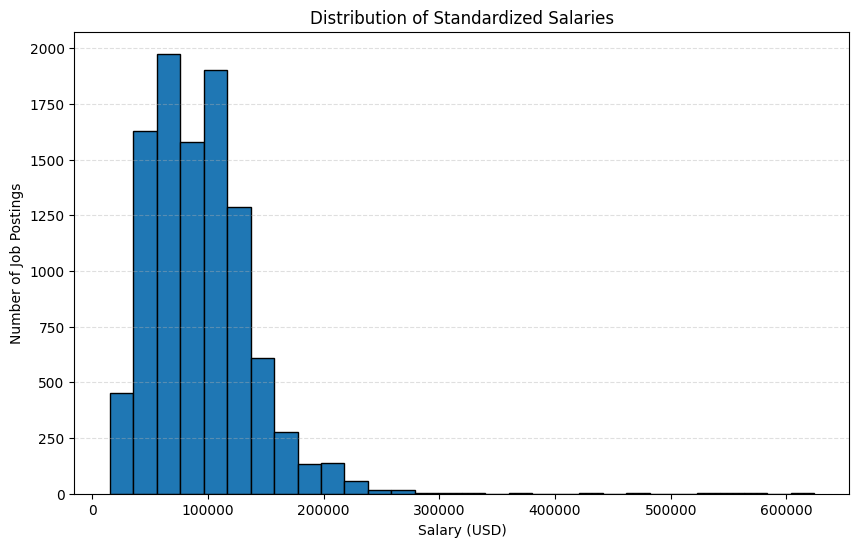

In [49]:
plt.figure(figsize=(10,6))
plt.hist(
    jobs["salary_standardized"].dropna(),
    bins = 30,
    edgecolor = "black"
)

plt.title("Distribution of Standardized Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Job Postings")

plt.grid(axis="y",linestyle="--",alpha =0.4)

plt.show()

Step 3: Business Insight


The salary distribution is positively (right) skewed, with most Data Analyst salaries concentrated between approximately $50,000 and $120,000 per year.
A small number of job postings offer exceptionally high salaries, creating several outliers that increase the overall average salary.
Therefore, the median salary provides a better representation of a typical Data Analyst salary than the mean.

Step 4: Business Recommendation

Job seekers should expect most Data Analyst positions to offer salaries between $50,000 and $120,000 annually.
While some positions provide significantly higher compensation, these opportunities are relatively rare and often require advanced skills, extensive experience, or specialized expertise.

Step 5: Interview Talking Point

I analyzed the salary distribution using a histogram because salary is a continuous numerical variable.
The visualization revealed a right-skewed distribution with several high-value outliers. By comparing the mean and median, I concluded that the median salary better represents the typical Data Analyst salary in the dataset.

Business Question 9

How Has Data Analyst Hiring Changed Over Time?

Business Goal

Analyze the job posting dates to identify hiring trends over time. This helps understand whether hiring demand is increasing, decreasing, or remaining stable during the data collection period.

Step 1: Mini Data Understanding

In [50]:
jobs["date_time"].head()

0    2023-08-04 03:00:13.797776
1    2023-08-04 03:00:13.797776
2    2023-08-04 03:00:13.797776
3    2023-08-04 03:00:13.797776
4    2023-08-04 03:00:13.797776
Name: date_time, dtype: str

In [51]:
jobs["date_time"].dtype

<StringDtype(storage='python', na_value=nan)>

In [52]:
jobs["date_time"].isnull().sum()

np.int64(0)

In [53]:
jobs["date_time"].describe()

count                          61953
unique                          6588
top       2023-08-04 03:00:13.797776
freq                              10
Name: date_time, dtype: object

Step 2: Data Quality Check

In [54]:
jobs["date_time"] = pd.to_datetime(jobs["date_time"])

In [55]:
jobs["month"] = jobs["date_time"].dt.to_period("M")

In [56]:
monthly_trend = (
    jobs.groupby("month")
    .size()
    .reset_index(name="Job Postings")
)

monthly_trend["month"] = monthly_trend["month"].astype(str)

monthly_trend

,month,Job Postings
0,2022-11,2159
1,2022-12,3329
2,2023-01,3682
3,2023-02,2828
4,2023-03,2727
5,2023-04,2493
6,2023-05,2357
7,2023-06,2362
8,2023-07,2560
9,2023-08,3008


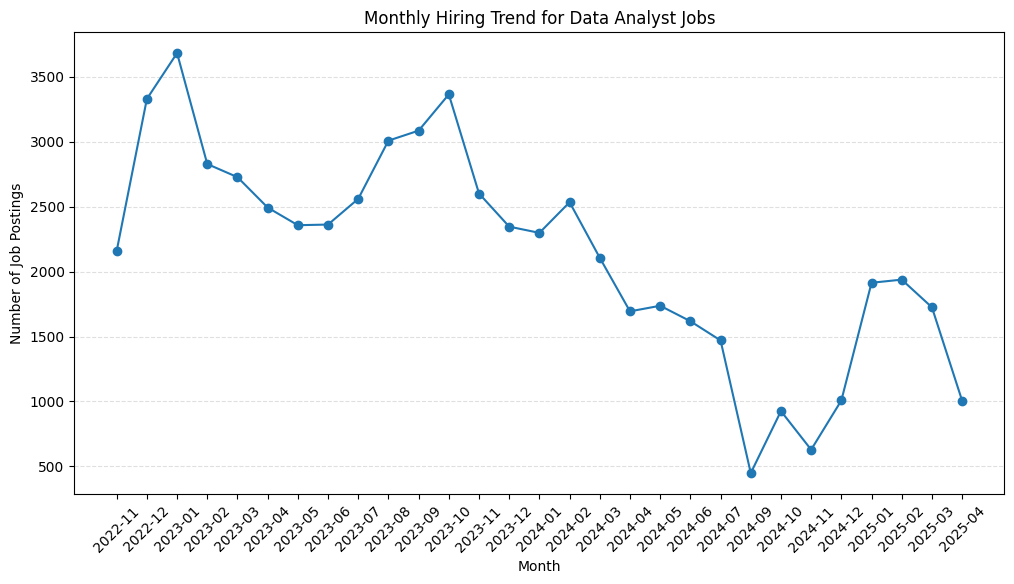

In [57]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_trend["month"],
    monthly_trend["Job Postings"],
    marker="o"
)

plt.title("Monthly Hiring Trend for Data Analyst Jobs")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

Step 3: Business Insight

The monthly hiring trend shows that Data Analyst job postings were highest around **November 2022** and gradually declined over time. The lowest hiring activity was observed around **July 2024**.

This indicates that hiring demand decreased during the analyzed period, although there were small fluctuations from month to month.

Step 4: Business Recommendation

Job seekers should actively monitor hiring trends and apply during periods of higher recruitment demand. Since hiring activity decreased over time in this dataset, candidates should strengthen their technical skills and remain flexible regarding job location and work arrangements to improve their employment opportunities.

Step 5: Interview Talking Point

I analyzed hiring trends by converting the posting date into a datetime format and aggregating job postings by month. Instead of using daily data, I summarized the results monthly to produce a clearer visualization and identify long-term hiring patterns.

In [58]:
jobs.to_csv("../data/processed/jobs_clean.csv", index=False)